In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "datasets" / "raw" / "train.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,borrow_block_number,borrow_timestamp,wallet_address,first_tx_timestamp,last_tx_timestamp,wallet_age,incoming_tx_count,outgoing_tx_count,net_incoming_tx_count,total_gas_paid_eth,...,market_max_drawdown_365d,market_natr,market_plus_di,market_plus_dm,market_ppo,market_rocp,market_rocr,unique_borrow_protocol_count,unique_lending_protocol_count,target
0,7711117,1.557197e+09,0x502cb8985b2c92a8d4bf309cdaa89de9be442708,1.537224e+09,1.557197e+09,19973049.0,199,438,-239,0.397391,...,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,0,1,1
1,7711123,1.557197e+09,0x502cb8985b2c92a8d4bf309cdaa89de9be442708,1.537224e+09,1.557197e+09,19973188.0,200,439,-239,0.399063,...,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,1,1,1
2,7711126,1.557197e+09,0x502cb8985b2c92a8d4bf309cdaa89de9be442708,1.537224e+09,1.557197e+09,19973238.0,201,440,-239,0.400895,...,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,1,1,1
3,7711672,1.557205e+09,0xa7ff0d561cd15ed525e31bbe0af3fe34ac2059f6,1.557191e+09,1.557198e+09,13922.0,8,56,-48,0.604001,...,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,0,1,0
4,7712572,1.557217e+09,0xbd9ed130a53cfafcf81502e4d35329a6c4d53410,1.557217e+09,1.557217e+09,264.0,2,3,-1,0.003008,...,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,0,1,0


In [3]:
df.shape

(442961, 78)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442961 entries, 0 to 442960
Data columns (total 78 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   borrow_block_number                      442961 non-null  int64  
 1   borrow_timestamp                         442961 non-null  float64
 2   wallet_address                           442961 non-null  object 
 3   first_tx_timestamp                       442961 non-null  float64
 4   last_tx_timestamp                        442961 non-null  float64
 5   wallet_age                               442961 non-null  float64
 6   incoming_tx_count                        442961 non-null  int64  
 7   outgoing_tx_count                        442961 non-null  int64  
 8   net_incoming_tx_count                    442961 non-null  int64  
 9   total_gas_paid_eth                       442961 non-null  float64
 10  avg_gas_paid_per_tx_eth         

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
borrow_block_number,442961.0,NaN,NaN,NaN,13049069.640271,2231888.135772,7711117.0,11624637.0,12705313.0,14816338.0,18251921.0
borrow_timestamp,442961.0,NaN,NaN,NaN,1629224531.32194,29723669.837436,1557197308.0,1610249614.0,1624652381.0,1653123335.0,1696117883.0
wallet_address,442961,74476,0x586e32930ac05127de429bd566eaa2758fcbd9bc,2759,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_tx_timestamp,442961.0,NaN,NaN,NaN,1593977602.7147,44859550.449324,1438269973.0,1570975978.0,1601186415.0,1621892624.0,1696060415.0
last_tx_timestamp,442961.0,NaN,NaN,NaN,1629119660.5704,29701789.447668,1557197074.0,1610198640.0,1624549488.0,1653020810.0,1701649379.0
...,...,...,...,...,...,...,...,...,...,...,...
market_rocp,442961.0,NaN,NaN,NaN,0.038512,0.176627,-0.545814,-0.068142,0.023303,0.138449,0.768294
market_rocr,442961.0,NaN,NaN,NaN,1.038512,0.176627,0.454186,0.931858,1.023303,1.138449,1.768294
unique_borrow_protocol_count,442961.0,NaN,NaN,NaN,0.975084,0.558809,0.0,1.0,1.0,1.0,4.0
unique_lending_protocol_count,442961.0,NaN,NaN,NaN,1.223742,0.443834,0.0,1.0,1.0,1.0,2.0


In [6]:
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

Series([], dtype: int64)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns
target_col = "target"

In [9]:
df[target_col].value_counts()

target
0    276761
1    166200
Name: count, dtype: int64

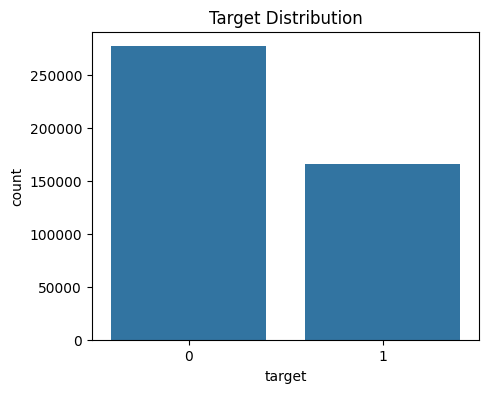

In [10]:
plt.figure(figsize=(5,4))

sns.countplot(
    data=df,
    x=target_col
)

plt.title("Target Distribution")
plt.show()

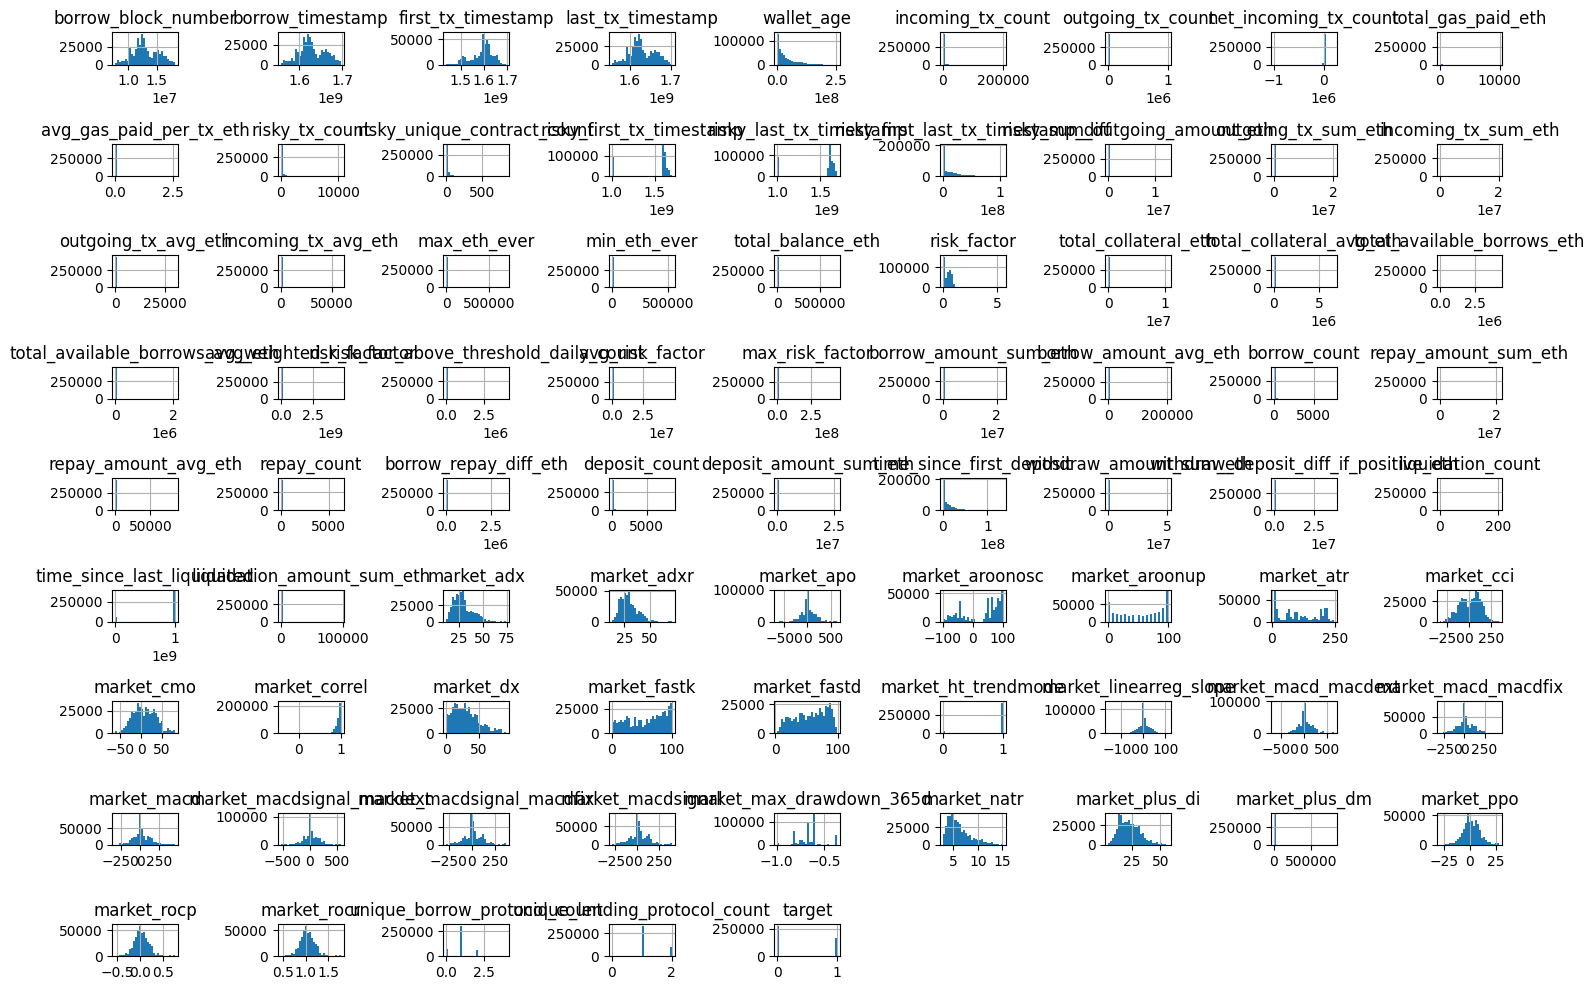

In [11]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns


numeric_cols

df[numeric_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

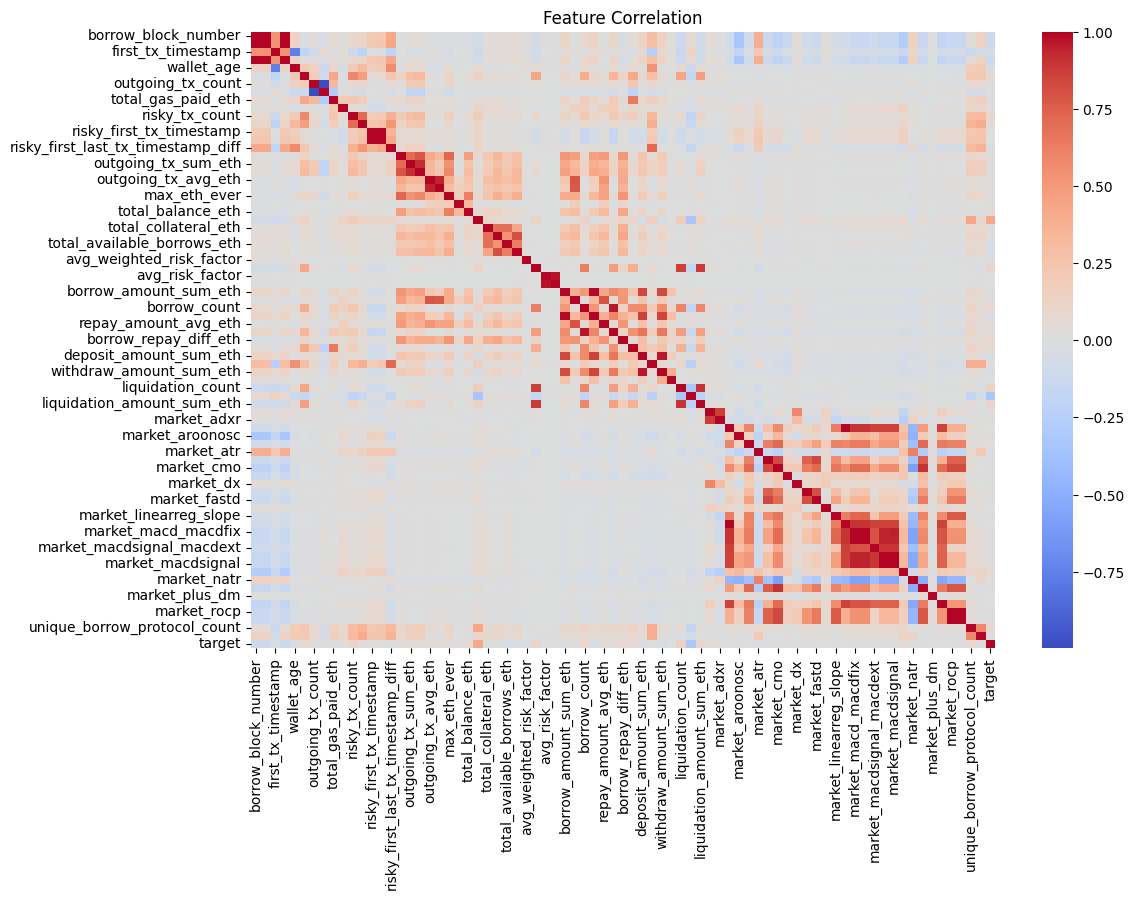

In [12]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation")
plt.show()

In [14]:
categorical_cols = df.select_dtypes(
    include="object"
).columns


categorical_cols

Index(['wallet_address'], dtype='object')

In [15]:
for col in categorical_cols:
    print(
        col,
        df[col].nunique()
    )

wallet_address 74476


In [16]:
for col in categorical_cols:
    print(
        f"{col}:",
        df[col].unique()[:10]
    )

wallet_address: ['0x502cb8985b2c92a8d4bf309cdaa89de9be442708'
 '0xa7ff0d561cd15ed525e31bbe0af3fe34ac2059f6'
 '0xbd9ed130a53cfafcf81502e4d35329a6c4d53410'
 '0xb3fbe25be2e8ca097e9ac924e94af000dd3a5663'
 '0x4654f56a64301b9b582f843f97332d96ead11ff8'
 '0x29bc5fb2b177dd3432661ee5c67e7d7008350fcf'
 '0xb00b6a03d101c091bde56f910ee1983f068d65f8'
 '0x2577a8539cb2194acd72f035dbb691ce5f406d3f'
 '0xa218a8346454c982912cf6d14c714663c2d510d8'
 '0x0006e4548aed4502ec8c844567840ce6ef1013f5']
